<a href="https://colab.research.google.com/github/mim-1999/california-housing-regression/blob/main/notebooks/01_eda_and_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# #Load Dataset and understand it

In [2]:
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing(as_frame=True)

# Convert to dataframe
df = housing.frame

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.shape

(20640, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [18]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [7]:

median_income = df['MedInc'].values

In [8]:
median_income_sorted = np.sort(median_income)

In [9]:
min_income = median_income_sorted.min()
max_income = median_income_sorted.max()
print(f"Minimum income is: {min_income:.4f}")
print(f"Maximum income is: {max_income:.4f}")

Minimum income is: 0.4999
Maximum income is: 15.0001


In [10]:
n = len(median_income)
Q1_index = int(0.25 * n)
Q3_index = int(0.75 * n)
Q1 = median_income_sorted[Q1_index]
Q3 = median_income_sorted[Q3_index]
print(f"Q1 is: {Q1:.4f}")
print(f"Q3 is: {Q3:.4f}")

Q1 is: 2.5637
Q3 is: 4.7437


In [11]:
median_position1 = int(0.5 * n)
median_position2 = int(0.5 * (n + 1))
median = (median_income_sorted[median_position1] + median_income_sorted[median_position2]) / 2
print(f"Median is:{median:.4f}")
print(f"Mean income is: {median_income_sorted.mean()}")

Median is:3.5349
Mean income is: 3.8706710029069766


In [12]:
IQR=Q3-Q1
print(f"IQR is: {IQR:.4f}")
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower bound is: {lower_bound:.4f}\nUpper bound is: {upper_bound:4f}")

IQR is: 2.1800
Lower bound is: -0.7063
Upper bound is: 8.013700


## Univariate Analysis

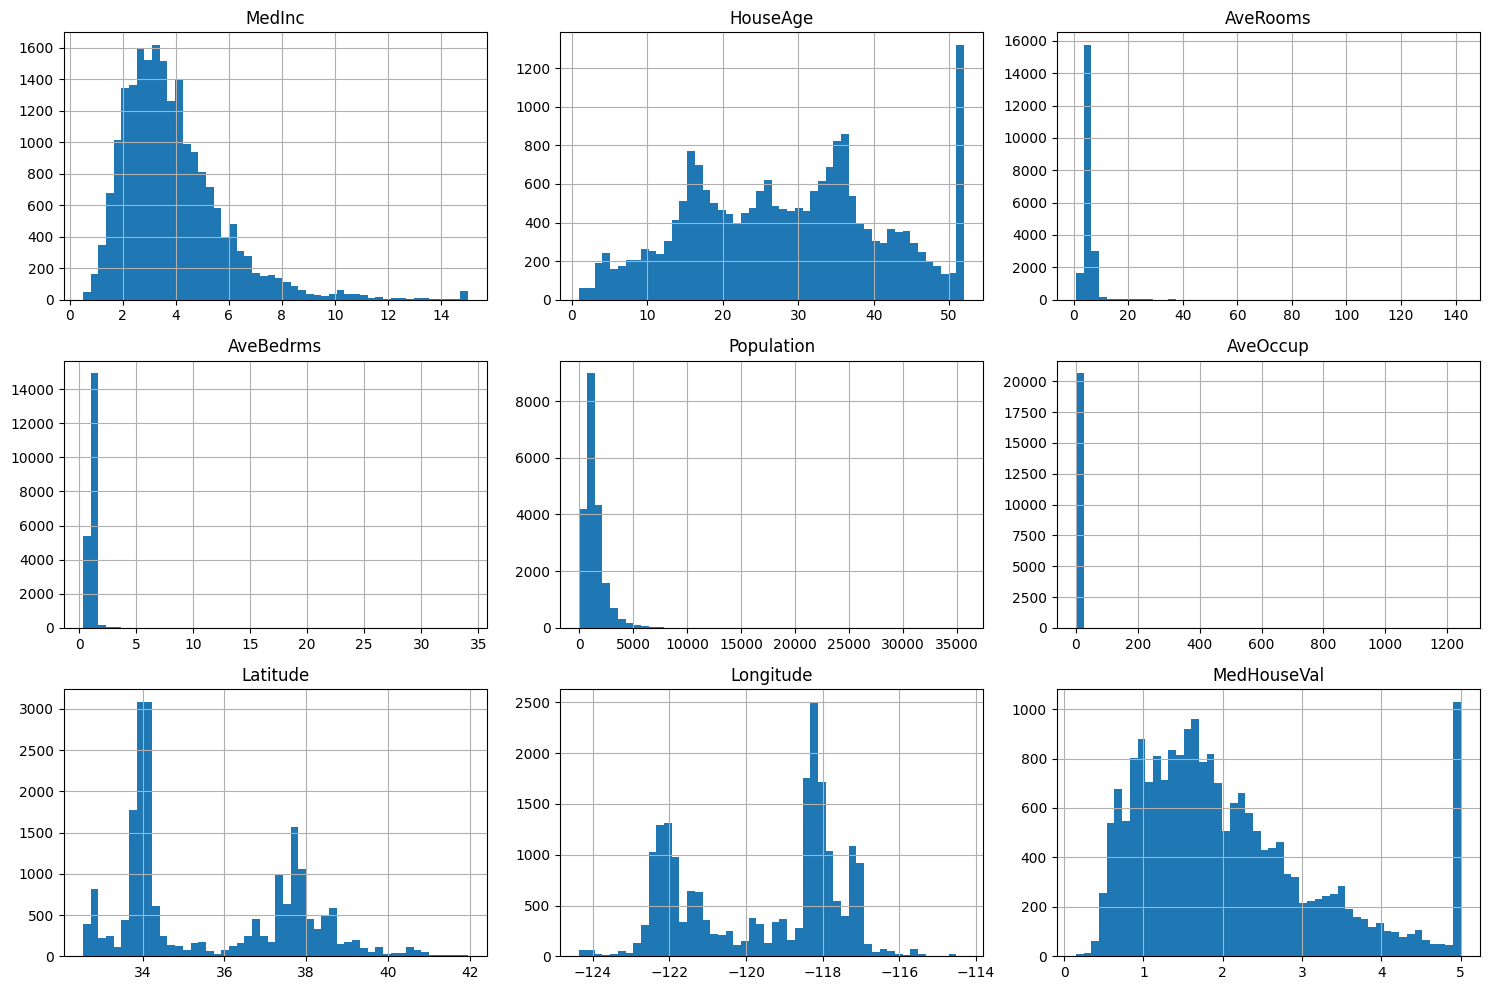

In [21]:
import os

df.hist(bins=50, figsize=(15, 10))
plt.tight_layout()

# Create the 'images' directory if it doesn't exist
os.makedirs('images', exist_ok=True)

plt.savefig('images/histograms_all.png', dpi=100)
plt.show()

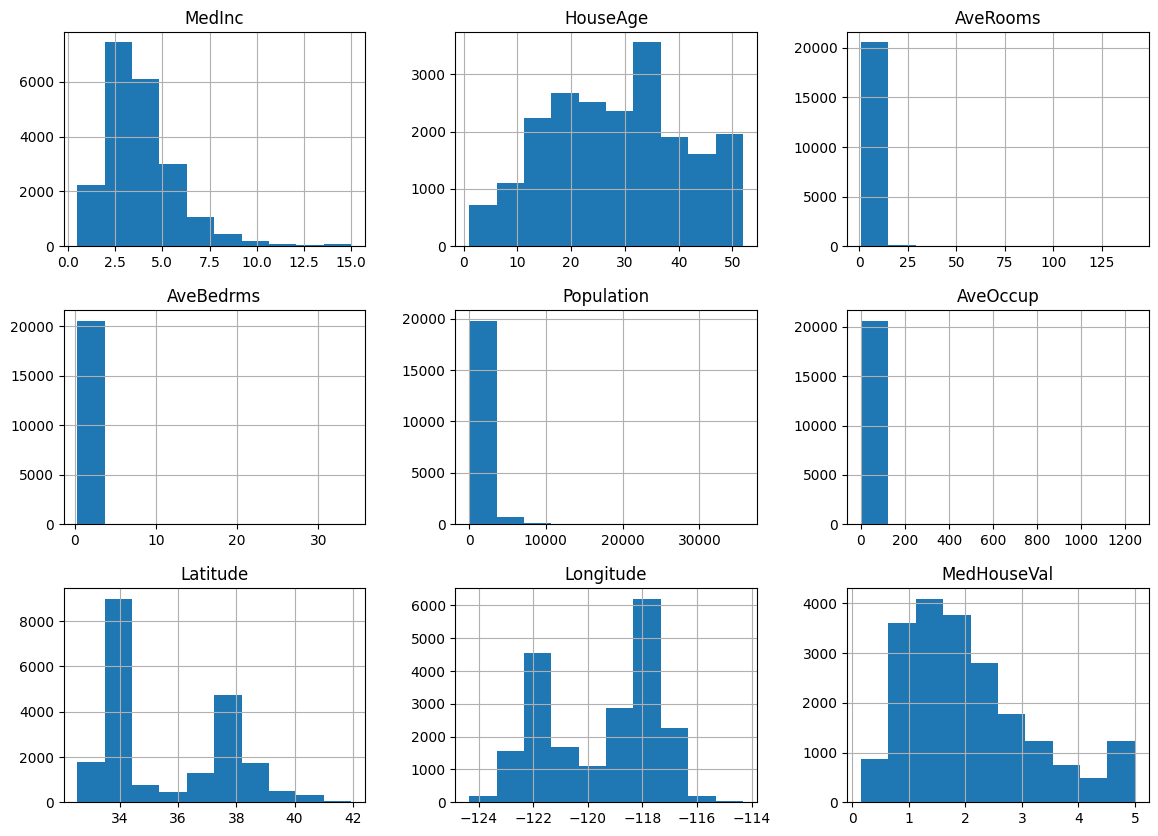

In [22]:
df.hist(figsize=(14,10))
plt.show()

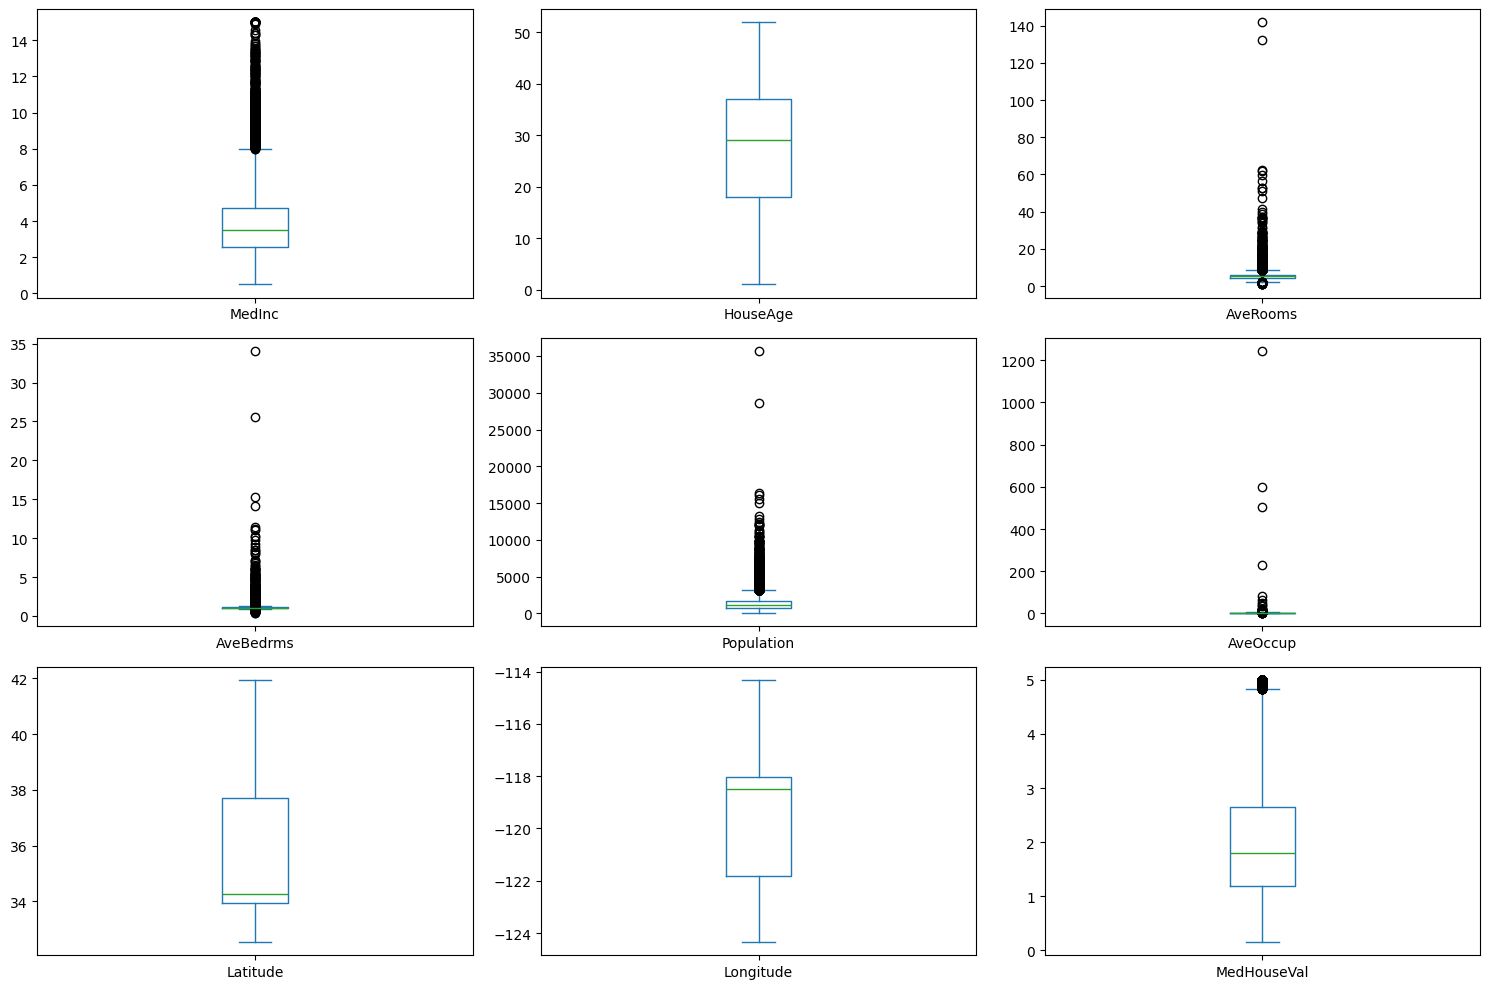

In [14]:
df.plot(
    kind="box",
    subplots=True,
    layout=(3,3),
    figsize=(15,10),
    sharex=False
)

plt.tight_layout()
plt.show()

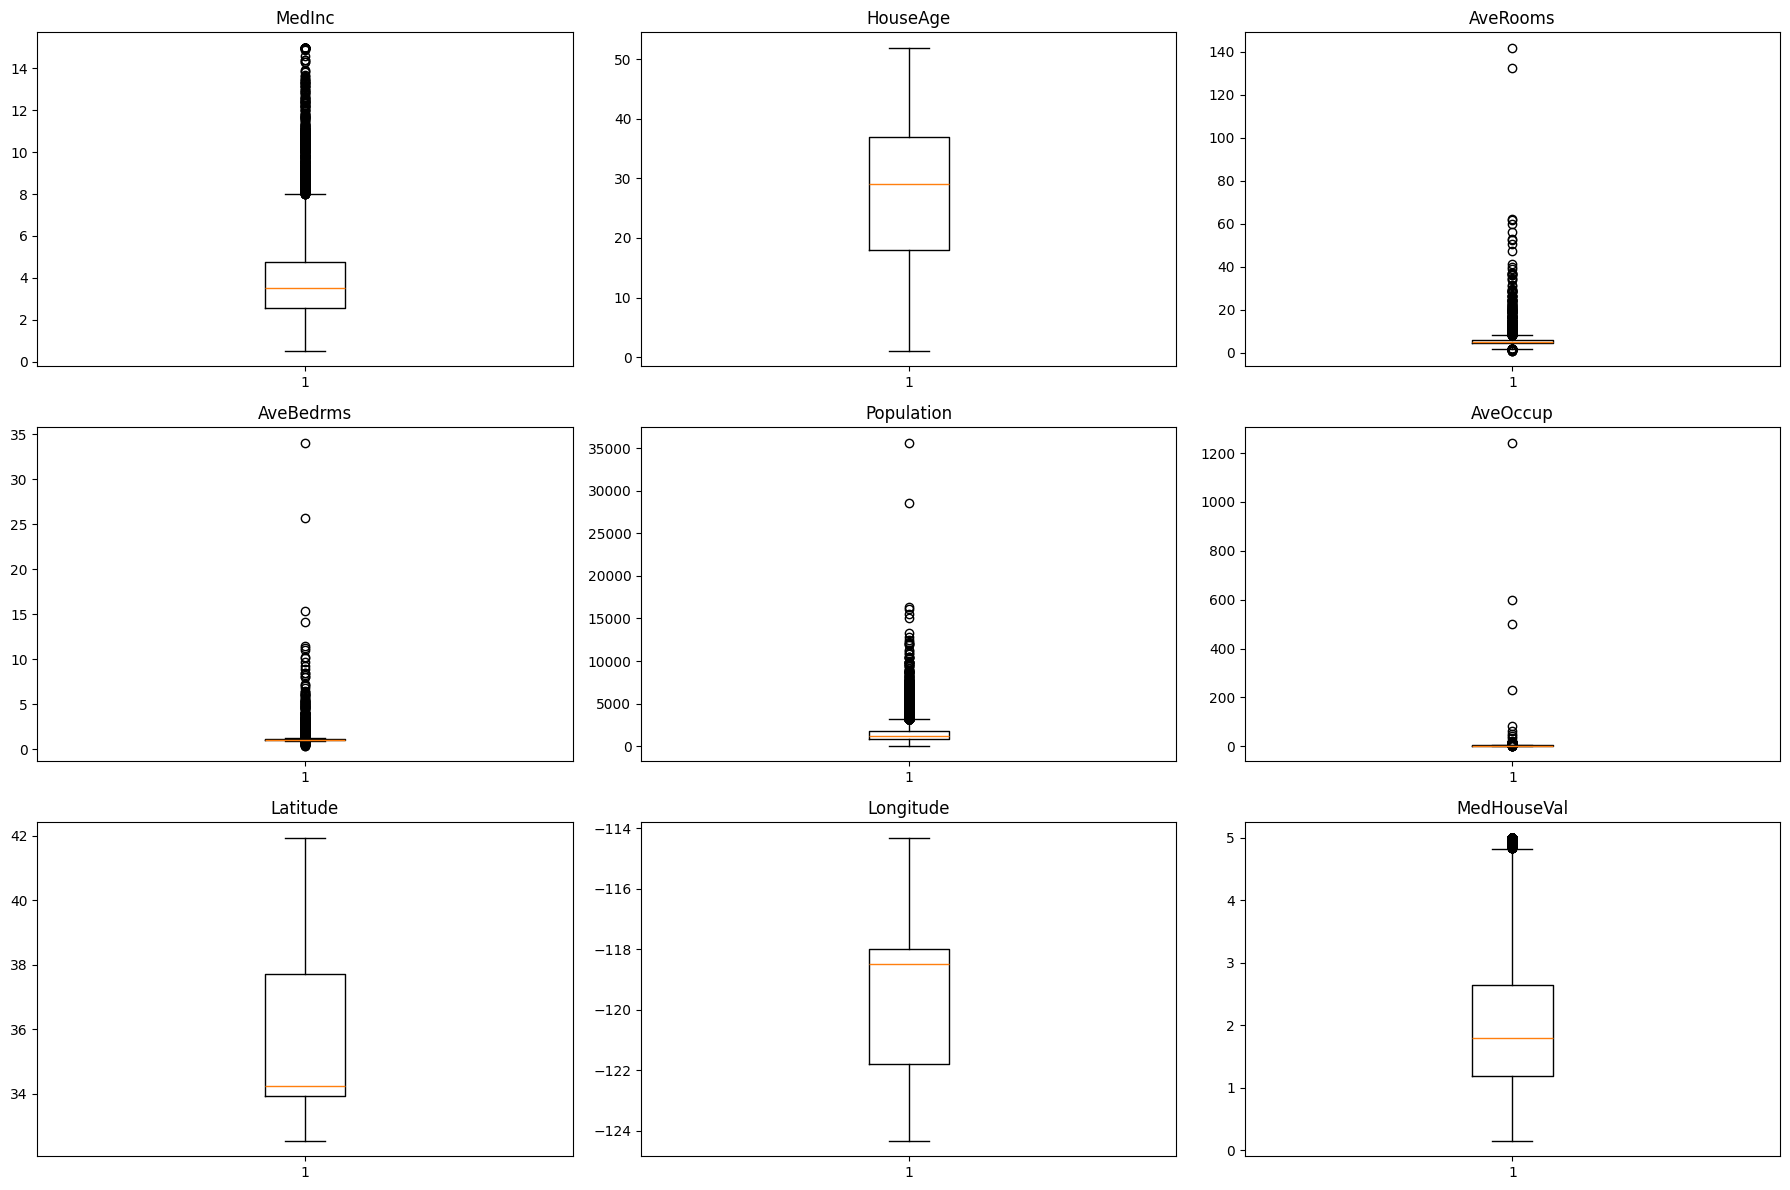

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig('images/boxplots_all.png', dpi=100)
plt.show()

In [28]:
# Get the exact count of outliers per column
def count_outliers_iqr(df,col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound)]
    return len(outliers)

for col in df.columns:
    print(f"Outliers in {col}: {count_outliers_iqr(df,col)}")

Outliers in MedInc: 681
Outliers in HouseAge: 0
Outliers in AveRooms: 511
Outliers in AveBedrms: 1424
Outliers in Population: 1196
Outliers in AveOccup: 711
Outliers in Latitude: 0
Outliers in Longitude: 0
Outliers in MedHouseVal: 1071


##Bivariate & Multivariate EDA

In [31]:
corr_matrix = df.corr()
corr_matrix['MedHouseVal'].sort_values(ascending=False)

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


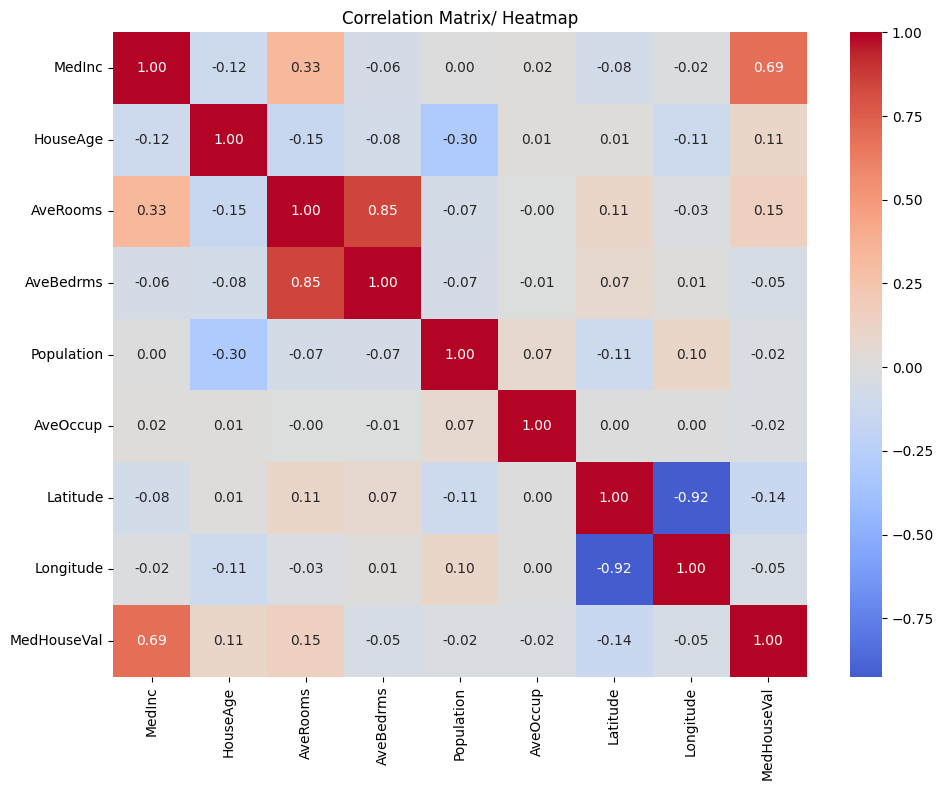

In [32]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Matrix/ Heatmap")
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=100)
plt.show()

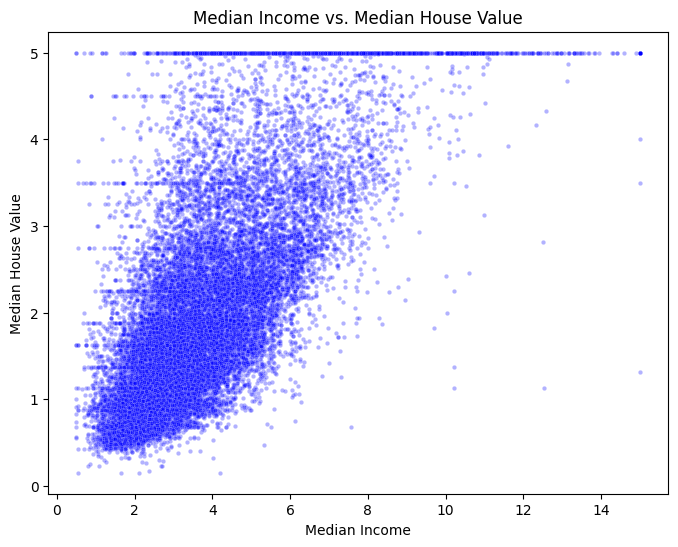

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="MedInc",
    y="MedHouseVal",
    data=df,
    color="blue", alpha=0.3, s=10
)
plt.title("Median Income vs. Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.savefig('images/medinc_vs_target.png', dpi=100)
plt.show()

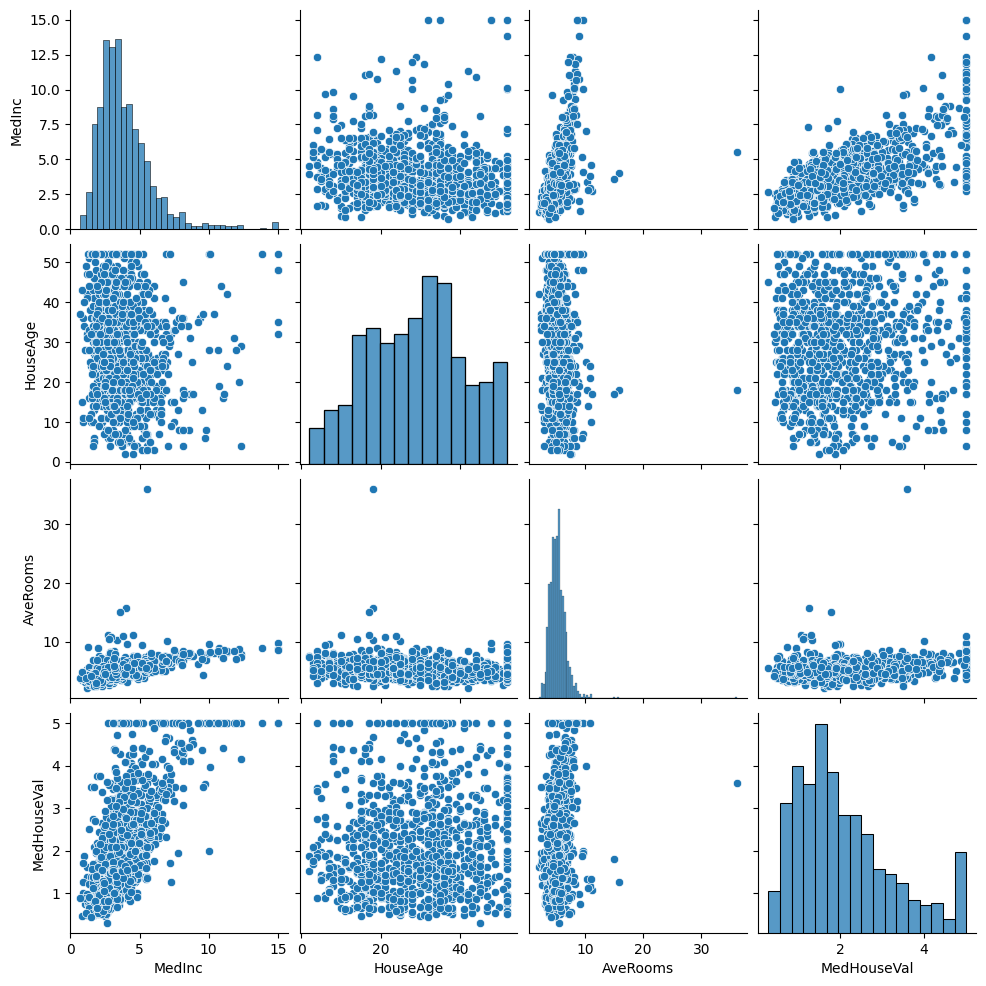

In [34]:
sample_df = df.sample(1000, random_state=42)
sns.pairplot(sample_df[['MedInc', 'HouseAge', 'AveRooms', 'MedHouseVal']],
             diag_kind='hist')
plt.savefig('images/pairplot.png', dpi=100)
plt.show()

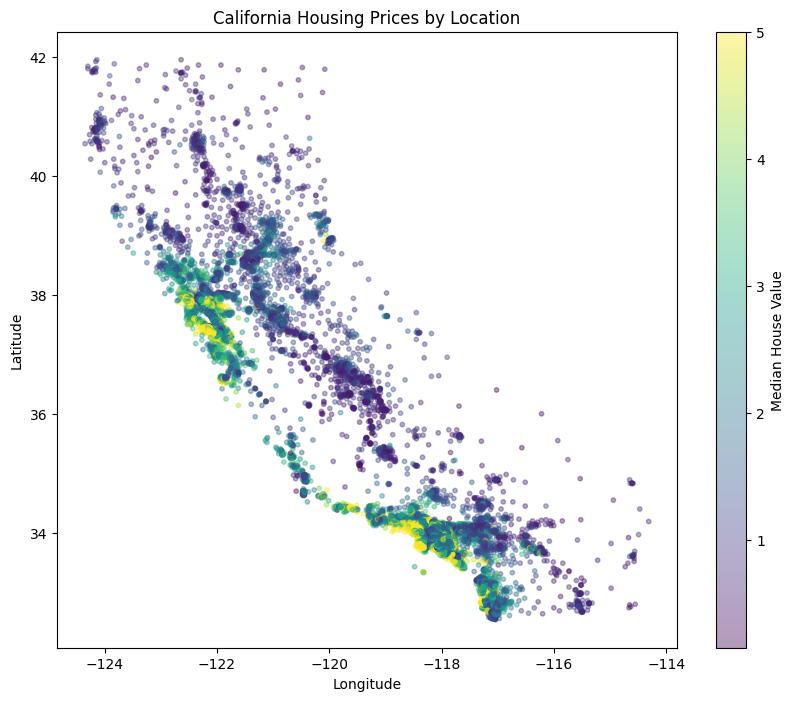

In [36]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['Longitude'], df['Latitude'],
                       c=df['MedHouseVal'], cmap='viridis',
                       alpha=0.4, s=10)
plt.colorbar(scatter, label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by Location')
plt.savefig('images/geo_price_map.png', dpi=100)
plt.show()

##Data Cleaning & Preprocessing

In [38]:
#handling outliers(capping)
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

for col in ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']:
    df = cap_outliers_iqr(df, col)


In [39]:
# Multicollinearity — check it properly with VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop('MedHouseVal', axis=1)

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values('VIF', ascending=False)

,feature,VIF
7,Longitude,1137.292563
6,Latitude,627.606288
3,AveBedrms,229.503486
2,AveRooms,47.295427
5,AveOccup,20.807789
0,MedInc,12.667628
1,HouseAge,7.627098
4,Population,4.989265


In [40]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.describe()  # mean ~0, std ~1 for every column

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04
mean,6.609700e-17,5.508083e-18,2.313395e-16,-6.774942e-16,1.335710e-16,-1.432102e-16,-1.079584e-15,-8.526513e-15
std,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00
min,-1.774299e+00,-2.196180e+00,-2.633335e+00,-2.387314e+00,-1.742525e+00,-2.530199e+00,-1.447568e+00,-2.385992e+00
25%,-6.881186e-01,-8.453931e-01,-6.933564e-01,-6.448912e-01,-7.184008e-01,-6.799133e-01,-7.967887e-01,-1.113209e+00
50%,-1.767951e-01,2.864572e-02,-6.067586e-02,-1.140809e-01,-2.233204e-01,-1.179684e-01,-6.422871e-01,5.389137e-01
75%,4.593063e-01,6.643103e-01,5.999626e-01,5.167240e-01,5.068904e-01,5.536104e-01,9.729566e-01,7.784964e-01
max,5.858286e+00,1.856182e+00,2.539941e+00,2.259147e+00,2.344827e+00,2.403896e+00,2.958068e+00,2.625280e+00


In [41]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.304740,1.057958,1336.959012,2.899647,35.631861,-119.569704
std,1.899822,12.585558,1.246177,0.080448,765.550830,0.691142,2.135952,2.003532
min,0.499900,1.000000,2.023219,0.865909,3.000000,1.150961,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,8.469878,1.239697,3132.000000,4.561041,41.950000,-114.310000


In [ ]:
print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16512, 8), (4128, 8), (16512,), (4128,))

In [ ]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred.shape

(4128,)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
print(f"R-squared score: {r2:.4f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.4f}")

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.4f}")



R-squared score: 0.5758
Mean Absolute Error: 0.5332
Mean Squared Error: 0.5559
Root Mean Squared Error: 0.7456


In [ ]:
residuals = y_test - y_pred
residuals.head()

,MedHouseVal
20046,-0.242123
3024,-1.306017
15663,2.290351
20484,-0.652926
9814,0.175343


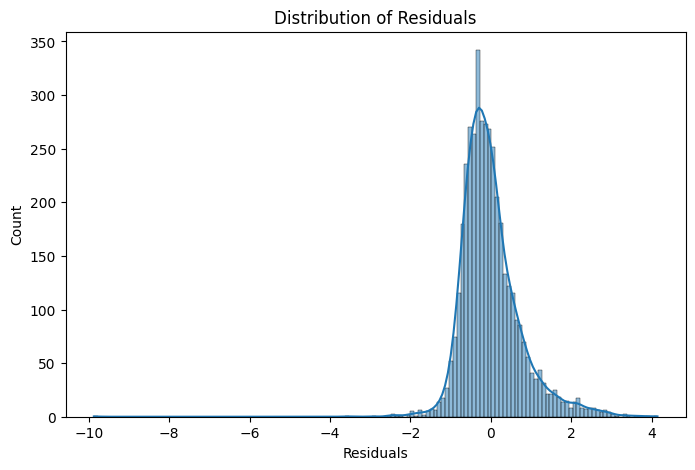

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.xlabel("Residuals")
plt.title("Distribution of Residuals")

plt.show()

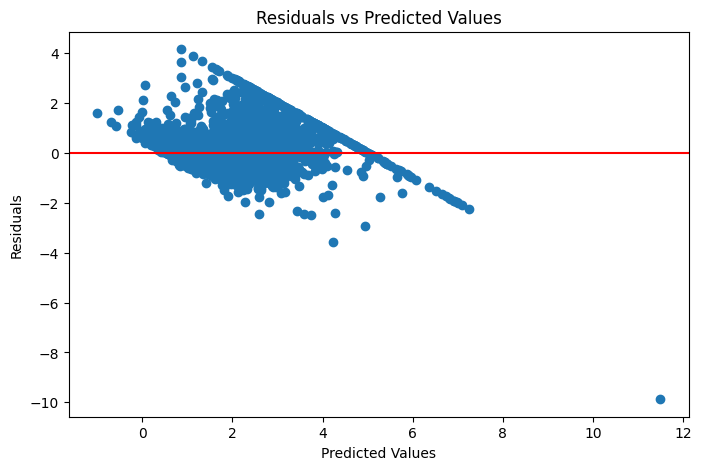

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Predicted Values")

plt.show()

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [ ]:
print(model.intercept_)
print(model.coef_)

-37.02327770606409
[ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
